In [ ]:
pip install yfinance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [ ]:
# DOWNLOADING THE S&P 500 DATASET

df = yf.download("^GSPC" , start = "2001-01-01" , end = "2025-01-01" )

/tmp/ipykernel_17595/3642593764.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^GSPC" , start = "2001-01-01" , end = "2025-01-01" )
[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2001-01-02,1283.270020,1320.280029,1276.050049,1320.280029,1129400000
2001-01-03,1347.560059,1347.760010,1274.619995,1283.270020,1880700000
2001-01-04,1333.339966,1350.239990,1329.140015,1347.560059,2131000000
2001-01-05,1298.349976,1334.770020,1294.949951,1333.339966,1430800000
2001-01-08,1295.859985,1298.349976,1276.290039,1298.349976,1115500000


In [ ]:
df.shape

(6037, 5)

In [ ]:
# CHECKING NULL VALUES

df.isnull().sum()

,,0
Price,Ticker,
Close,^GSPC,0
High,^GSPC,0
Low,^GSPC,0
Open,^GSPC,0
Volume,^GSPC,0


In [ ]:
# Removing the Multi-Index Labels

df.columns = df.columns.droplevel(1)
df.columns.name = None
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2001-01-02,1283.270020,1320.280029,1276.050049,1320.280029,1129400000
2001-01-03,1347.560059,1347.760010,1274.619995,1283.270020,1880700000
2001-01-04,1333.339966,1350.239990,1329.140015,1347.560059,2131000000
2001-01-05,1298.349976,1334.770020,1294.949951,1333.339966,1430800000
2001-01-08,1295.859985,1298.349976,1276.290039,1298.349976,1115500000


In [ ]:
# REMOVING THE UNNECESSARY COLUMNS And Renaming columns

df = df[["Close"]]

df.rename(columns = {"Close" : "Price"} , inplace = True)

In [ ]:
# CREATING RETURNS ( LOG RETURNS )

df["return"] = np.log( df["Price"] / df["Price"].shift(1) )

df.dropna(inplace = True)

df.head()

,Price,return
Date,,
2001-01-03,1347.560059,0.048884
2001-01-04,1333.339966,-0.010609
2001-01-05,1298.349976,-0.026593
2001-01-08,1295.859985,-0.001920
2001-01-09,1300.800049,0.003805


In [ ]:
# VOLATILITY

df["volatility"] = df["return"].rolling(window = 20).std()

df.dropna(inplace =True)

df.head()

,Price,return,volatility
Date,,,
2001-01-31,1366.010010,-0.005636,0.014231
2001-02-01,1373.469971,0.005446,0.009361
2001-02-02,1349.469971,-0.017628,0.009932
2001-02-05,1354.310059,0.003580,0.007602
2001-02-06,1352.260010,-0.001515,0.007591


In [ ]:
#DRAWDOWN

df["running_max"] = df["Price"].cummax()

df["drawdown"] = (df["Price"] - df["running_max"]) / df["running_max"]

In [ ]:
df.head()

,Price,return,volatility,running_max,drawdown
Date,,,,,
2001-01-31,1366.010010,-0.005636,0.014231,1366.010010,0.000000
2001-02-01,1373.469971,0.005446,0.009361,1373.469971,0.000000
2001-02-02,1349.469971,-0.017628,0.009932,1373.469971,-0.017474
2001-02-05,1354.310059,0.003580,0.007602,1373.469971,-0.013950
2001-02-06,1352.260010,-0.001515,0.007591,1373.469971,-0.015443


In [ ]:
# DRAWDOWN DURATION

duration = []
count = 0

for dd in df["drawdown"]:

    if dd == 0:
        count = 0
    else:
        count += 1

    duration.append(count)

df["drawdown_duration"] = duration

In [ ]:
max_duration = df["drawdown_duration"].max()
print(max_duration)

#THIS IS THE DOTCOM CRASH THAT HAPPENED FROM 2000-2007

1437


**PREPARATION FOR AI MODELS**

In [ ]:
#ROLLING FEATURES ..

df["rolling_mean_20"] = df["return"].rolling(20).mean()

df["rolling_vol_20"]  = df["return"].rolling(20).std()

In [ ]:
df["rolling_mean_100"] = df["return"].rolling(100).mean()

df["rolling_vol_100"]  = df["return"].rolling(100).std()

In [ ]:
df.dropna(inplace = True)

In [ ]:
df

,Price,return,volatility,running_max,drawdown,drawdown_duration,rolling_mean_20,rolling_vol_20,rolling_mean_100,rolling_vol_100
Date,,,,,,,,,,
2001-06-22,1225.349976,-0.009495,0.009308,1373.469971,-0.107844,98,-0.002694,0.009308,-0.001143,0.014512
2001-06-25,1218.599976,-0.005524,0.009084,1373.469971,-0.112758,99,-0.002375,0.009084,-0.001142,0.014511
2001-06-26,1216.760010,-0.001511,0.008993,1373.469971,-0.114098,100,-0.002060,0.008993,-0.001211,0.014496
2001-06-27,1211.069946,-0.004687,0.008427,1373.469971,-0.118241,101,-0.001505,0.008427,-0.001082,0.014406
2001-06-28,1226.199951,0.012416,0.008832,1373.469971,-0.107225,102,-0.001193,0.008832,-0.000994,0.014462
...,...,...,...,...,...,...,...,...,...,...
2024-12-24,6040.040039,0.010982,0.008843,6090.270020,-0.008248,12,0.000438,0.008843,0.001220,0.008827
2024-12-26,6037.589844,-0.000406,0.008756,6090.270020,-0.008650,13,0.000132,0.008756,0.001520,0.008230
2024-12-27,5970.839844,-0.011117,0.009076,6090.270020,-0.019610,14,-0.000233,0.009076,0.001306,0.008278


In [ ]:
# NORMALIZING VALUES

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df.loc[:])

In [ ]:
df_scaled = pd.DataFrame(df_scaled , columns = df.columns , index = df.index)

In [ ]:
df_scaled.head()

,Price,return,volatility,running_max,drawdown,drawdown_duration,rolling_mean_20,rolling_vol_20,rolling_mean_100,rolling_vol_100
Date,,,,,,,,,,
2001-06-22,-0.736406,-0.806692,-0.118009,-0.798208,0.076784,-0.633422,-1.259531,-0.118009,-1.390794,0.658217
2001-06-25,-0.741733,-0.478415,-0.151136,-0.798208,0.035556,-0.631101,-1.124101,-0.151136,-1.389688,0.658158
2001-06-26,-0.743186,-0.146691,-0.164417,-0.798208,0.024317,-0.628780,-0.989712,-0.164417,-1.458629,0.655567
2001-06-27,-0.747677,-0.409266,-0.247921,-0.798208,-0.010437,-0.626460,-0.753609,-0.247921,-1.330393,0.640167
2001-06-28,-0.735735,1.004580,-0.188239,-0.798208,0.081975,-0.624139,-0.620928,-0.188239,-1.242840,0.649668


In [ ]:
df_scaled.describe()

,Price,return,volatility,running_max,drawdown,drawdown_duration,rolling_mean_20,rolling_vol_20,rolling_mean_100,rolling_vol_100
count,5.918000e+03,5.918000e+03,5.918000e+03,5.918000e+03,5.918000e+03,5.918000e+03,5.918000e+03,5.918000e+03,5.918000e+03,5.918000e+03
mean,-1.536828e-16,-1.800970e-17,1.152621e-16,7.684139e-17,7.684139e-17,-3.842070e-17,-4.802587e-18,1.152621e-16,-5.763104e-17,7.684139e-17
std,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00
min,-1.169560e+00,-1.057431e+01,-1.185337e+00,-7.982078e-01,-3.781390e+00,-8.608479e-01,-7.993961e+00,-1.185337e+00,-5.560807e+00,-1.199387e+00
25%,-7.634002e-01,-3.944022e-01,-6.000866e-01,-6.878971e-01,-5.467468e-01,-8.329998e-01,-4.345347e-01,-6.000866e-01,-3.928457e-01,-6.004416e-01
50%,-4.707184e-01,3.395186e-02,-2.517534e-01,-6.430217e-01,2.996399e-01,-4.825778e-01,1.551967e-01,-2.517534e-01,1.550890e-01,-3.378650e-01
75%,5.209310e-01,4.579533e-01,2.871253e-01,4.332228e-01,8.697355e-01,6.864625e-01,5.683403e-01,2.871253e-01,6.035091e-01,3.418350e-01
max,3.103210e+00,9.036124e+00,7.601421e+00,2.931636e+00,9.814810e-01,2.473963e+00,4.379079e+00,7.601421e+00,3.810764e+00,4.767082e+00


In [ ]:
# DISCOVERING THE MARKET REGIMES i.e. the clusters using KMeans

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, max_iter = 300 , random_state = 42)

df["regime"] = kmeans.fit_predict(df_scaled)


In [ ]:
df["regime"].value_counts()

,count
regime,
1,3027
0,2370
2,521


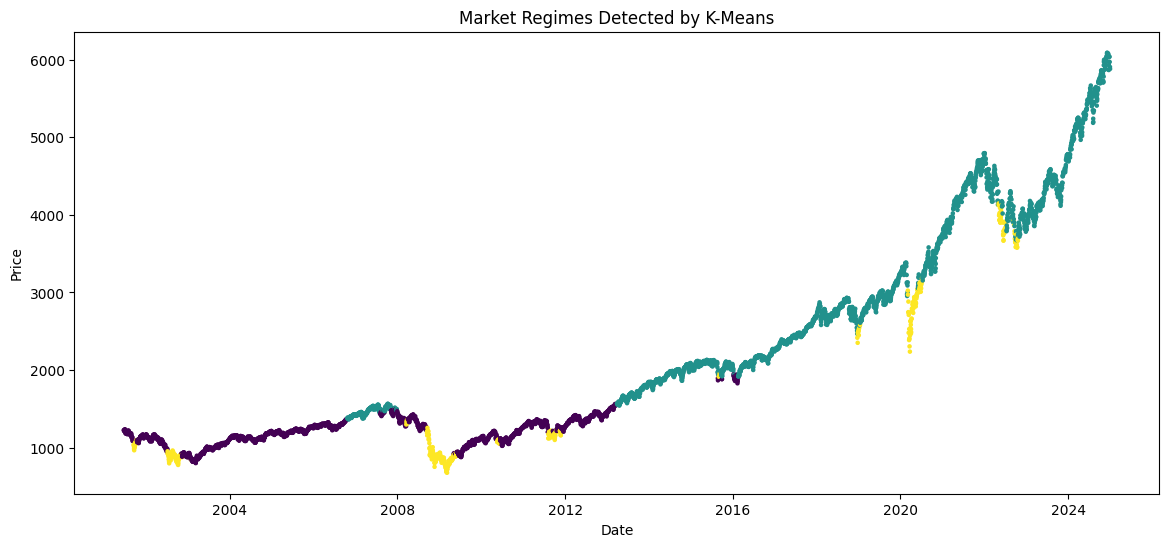

In [ ]:

plt.figure(figsize=(14,6))

plt.scatter(df.index, df["Price"],
            c=df["regime"],
            cmap="viridis",
            s=5)

plt.title("Market Regimes Detected by K-Means")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

#PURPLE = CALM MARKET , GREEN = GROWTH PERIOD , YELLOW = HIGH VOLATILITY

In [ ]:
# UNDERSTANDING EACH REGIME and Categorising them

df.groupby("regime")[["return" , "volatility" , "drawdown"]].mean()

,return,volatility,drawdown
regime,,,
0,0.000182,0.009378,-0.181732
1,0.000708,0.007969,-0.033694
2,-0.001951,0.025864,-0.306507



**1.Regime 1: Bull market characterized by strong returns and low volatility.**

**2.Regime 0: Normal or transitional market conditions.**

**3.Regime 2: Crisis regime marked by extreme volatility and deep drawdowns.**




**Applying AI Models**

**1. HMM**

In [ ]:
pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 1.5 MB/s eta 0:00:00


In [ ]:
hmm_features = df_scaled[ ["return" , "volatility" , "drawdown"] ].values

In [ ]:
hmm_features

array([[-0.80669158, -0.11800901,  0.07678384],
       [-0.47841529, -0.15113615,  0.03555574],
       [-0.14669084, -0.16441671,  0.02431748],
       ...,
       [-0.94080448, -0.15222473,  0.81697332],
       [-0.91124046, -0.12534836,  0.72895514],
       [-0.37674802, -0.12701503,  0.6940921 ]])

In [ ]:
from hmmlearn.hmm import GaussianHMM

hmm = GaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=1000,
        random_state=42
)

hmm.fit(hmm_features)

df["hmm_regime"] = hmm.predict(hmm_features)

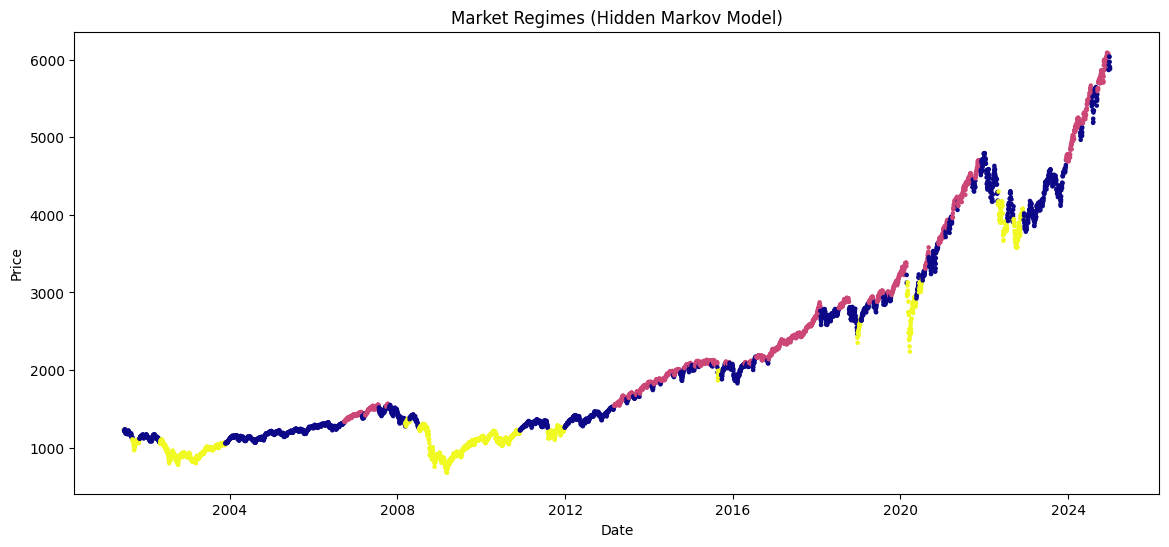

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.scatter(
    df.index,
    df["Price"],
    c=df["hmm_regime"],
    cmap="plasma",
    s=5
)

plt.title("Market Regimes (Hidden Markov Model)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [ ]:
df.groupby("hmm_regime")[["return", "volatility", "drawdown" ]].mean()

,return,volatility,drawdown
hmm_regime,,,
0,0.000086,0.009062,-0.102133
1,0.000823,0.006006,-0.007095
2,-0.000104,0.017370,-0.285952


**• Regime 1 (Bull State): Characterized by high returns, low volatility, and minimal drawdowns.**

**• Regime 0 (Neutral State): Moderate volatility with stable market behaviour.**

**• Regime 2 (Crisis State): Negative returns, elevated volatility, and large drawdowns indicating market stress.**


In [ ]:
hmm.transmat_

array([[9.82377007e-001, 1.34650086e-002, 4.15798390e-003],
       [2.03832986e-002, 9.79616701e-001, 4.56357538e-024],
       [8.70489217e-003, 4.79182739e-135, 9.91295108e-001]])

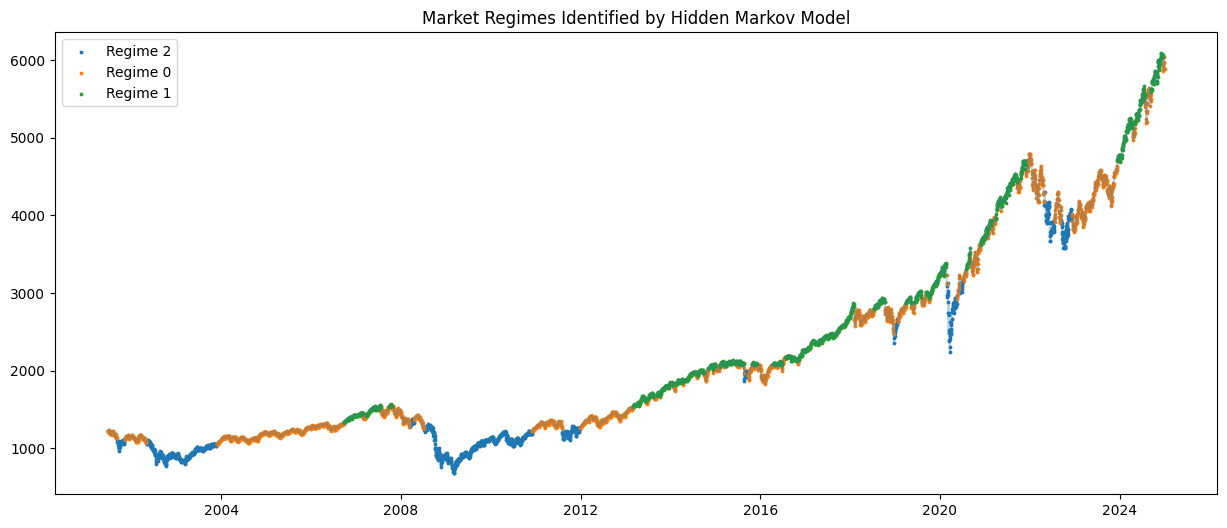

In [ ]:
plt.figure(figsize=(15,6))

for regime in df["hmm_regime"].unique():
    subset = df[df["hmm_regime"] == regime]
    plt.scatter(subset.index, subset["Price"], s=3, label=f"Regime {regime}")

plt.plot(df.index, df["Price"], alpha=0.3)

plt.legend()
plt.title("Market Regimes Identified by Hidden Markov Model")
plt.show()

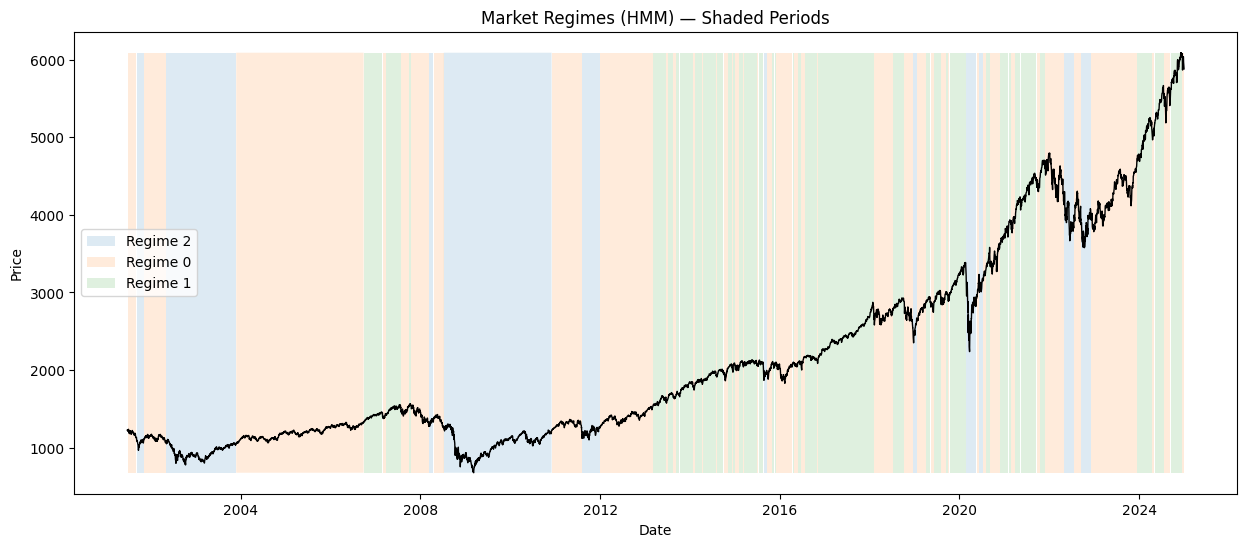

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df["Price"], color="black", linewidth=1)

for regime in df["hmm_regime"].unique():
    plt.fill_between(
        df.index,
        df["Price"].min(),
        df["Price"].max(),
        where=(df["hmm_regime"] == regime),
        alpha=0.15,
        label=f"Regime {regime}"
    )

plt.title("Market Regimes (HMM) — Shaded Periods")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

In [ ]:
regime_duration = (
    df.groupby(
        (df["hmm_regime"] != df["hmm_regime"].shift()).cumsum()
    )
    .agg({
        "hmm_regime": "first",
        "Price": "count"
    })
    .rename(columns={"Price": "duration"})
)

# FIX
regime_duration = regime_duration.reset_index(drop=True)

regime_duration.groupby("hmm_regime")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
hmm_regime,,,,,,,,
0,47.0,57.957447,115.381401,2.0,8.5,20.0,50.5,714.0
1,35.0,51.142857,52.863945,9.0,21.0,36.0,71.5,310.0
2,12.0,117.000000,186.697616,1.0,20.0,47.5,72.0,607.0


In [ ]:
#TIME SPENT IN EACH REGIME

df["hmm_regime"].value_counts(normalize=True) * 100

,proportion
hmm_regime,
0,46.029064
1,30.246705
2,23.724231


**CHAPTER 4 : BENCHMARK HOLD , LIKE AN INVESTOR**

In [ ]:
#SO NOW THE GOOD REGIME WAS 1  , THAT IS IN THIS REGIME WE CAN INVEST

GOOD_REGIME = 1

In [ ]:
# daily return equals market return
df["buy_hold_return"] = df["return"]

# cumulative wealth growth
df["buy_hold_cum"] = (1 + df["buy_hold_return"]).cumprod()

In [ ]:
df[["buy_hold_return","buy_hold_cum"]].tail()

,buy_hold_return,buy_hold_cum
Date,,
2024-12-24,0.010982,3.160977
2024-12-26,-0.000406,3.159695
2024-12-27,-0.011117,3.124567
2024-12-30,-0.010760,3.090948
2024-12-31,-0.004294,3.077675


In [ ]:
# Regime-Based Strategy

# start with zero return (cash position)
df["strategy_return"] = 0.000008

# invest only in GOOD regime
df.loc[df["hmm_regime"] == GOOD_REGIME, "strategy_return"] = df["return"]

# cumulative wealth
df["strategy_cum"] = (1 + df["strategy_return"]).cumprod()

In [ ]:
df[["hmm_regime","return","strategy_return"]].head(15)

,hmm_regime,return,strategy_return
Date,,,
2001-06-22,2,-0.009495,0.000008
2001-06-25,0,-0.005524,0.000008
2001-06-26,0,-0.001511,0.000008
2001-06-27,0,-0.004687,0.000008
2001-06-28,0,0.012416,0.000008
2001-06-29,0,-0.001485,0.000008
2001-07-02,0,0.010028,0.000008
2001-07-03,0,-0.001837,0.000008
2001-07-05,0,-0.012398,0.000008


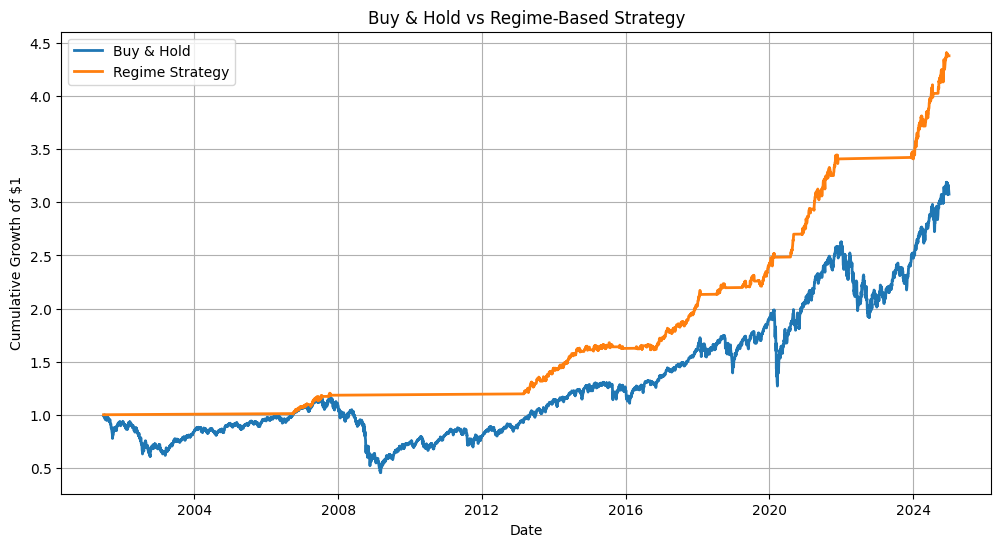

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df.index, df["buy_hold_cum"], label="Buy & Hold", linewidth=2)
plt.plot(df.index, df["strategy_cum"], label="Regime Strategy", linewidth=2)

plt.title("Buy & Hold vs Regime-Based Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.grid(True)

plt.show()

**METRICS**

In [ ]:
import numpy as np

# -----------------------------
# Buy & Hold Metrics
# -----------------------------
bh_total_return = df["buy_hold_cum"].iloc[-1] - 1
bh_volatility = df["buy_hold_return"].std() * np.sqrt(252)
bh_sharpe = (df["buy_hold_return"].mean() /
             df["buy_hold_return"].std()) * np.sqrt(252)

# -----------------------------
# Regime Strategy Metrics
# -----------------------------
st_total_return = df["strategy_cum"].iloc[-1] - 1
st_volatility = df["strategy_return"].std() * np.sqrt(252)
st_sharpe = (df["strategy_return"].mean() /
             df["strategy_return"].std()) * np.sqrt(252)

print("BUY & HOLD")
print("Total Return:", bh_total_return)
print("Volatility:", bh_volatility)
print("Sharpe Ratio:", bh_sharpe)

print("\nREGIME STRATEGY")
print("Total Return:", st_total_return)
print("Volatility:", st_volatility)
print("Sharpe Ratio:", st_sharpe)

BUY & HOLD
Total Return: 2.077675372473362
Volatility: 0.19204754608254876
Sharpe Ratio: 0.3456959234546643

REGIME STRATEGY
Total Return: 3.3795626509673973
Volatility: 0.049320483795136906
Sharpe Ratio: 1.299965434103626


In [ ]:
# -----------------------------
# Maximum Drawdown Function
# -----------------------------
def max_drawdown(cum_returns):
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    return drawdown.min()

# Buy & Hold Drawdown
bh_max_dd = max_drawdown(df["buy_hold_cum"])

# Strategy Drawdown
st_max_dd = max_drawdown(df["strategy_cum"])

print("Buy & Hold Max Drawdown:", bh_max_dd)
print("Strategy Max Drawdown:", st_max_dd)

Buy & Hold Max Drawdown: -0.6102973069209954
Strategy Max Drawdown: -0.0449627381091753


In [ ]:
df.to_csv("final_regime_results.csv")